<a href="https://colab.research.google.com/github/KoKory7/Practica-merge/blob/main/Copy_of_Collab_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FORMA DEL DATASET: (1500, 11)

TIPOS DE DATOS:
 Departamento                       object
Municipio                          object
Zona                               object
Acceso_Electricidad                object
Horas_Servicio_Dia                  int64
Ingresos_Hogar_Miles_COP            int64
Estrato                             int64
Nivel_Educativo_Jefe               object
Fuente_Energia                     object
Costo_Mensual_Energia_Miles_COP     int64
Tecnologia_Renovable               object
dtype: object

PRIMERAS FILAS:
   Departamento    Municipio    Zona Acceso_Electricidad  Horas_Servicio_Dia  \
0     Amazonas  Municipio_4   Rural                  Sí                   5   
1  Bogotá D.C.  Municipio_4   Rural                  Sí                   7   
2      Vichada  Municipio_3   Rural                  Sí                  10   
3    Antioquia  Municipio_4   Rural                  Sí                  16   
4    Antioquia  Municipio_2  Urbana                  Sí        

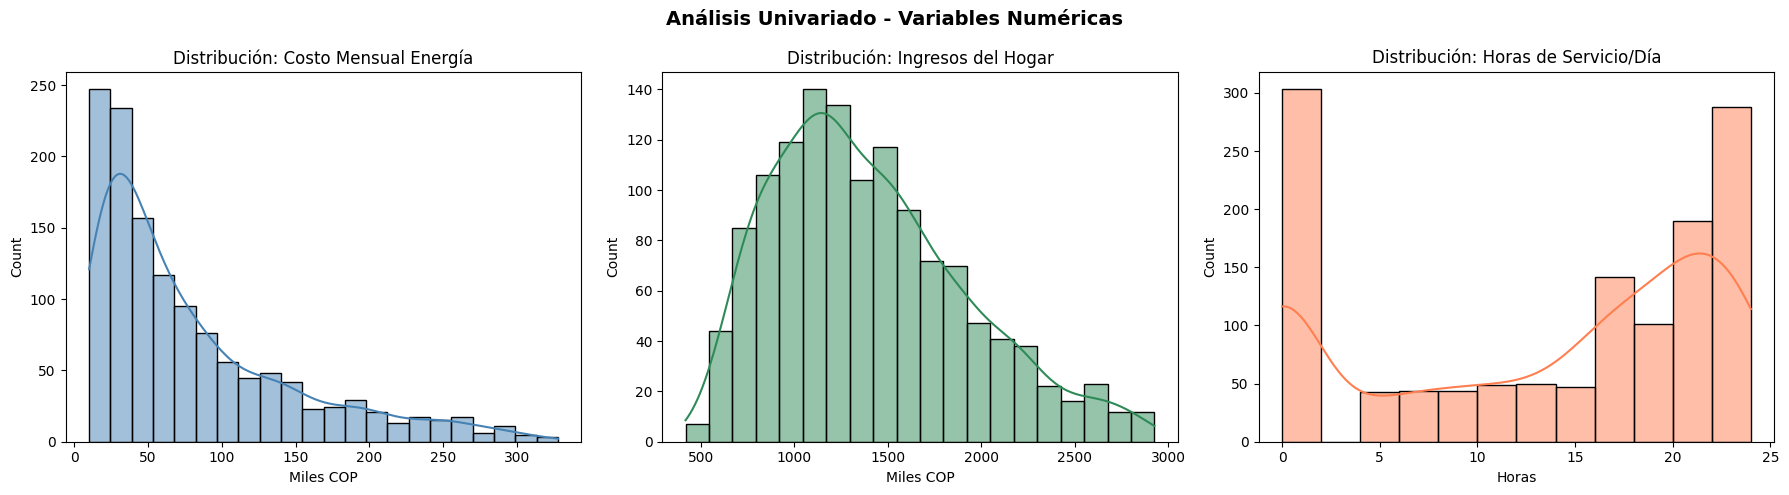

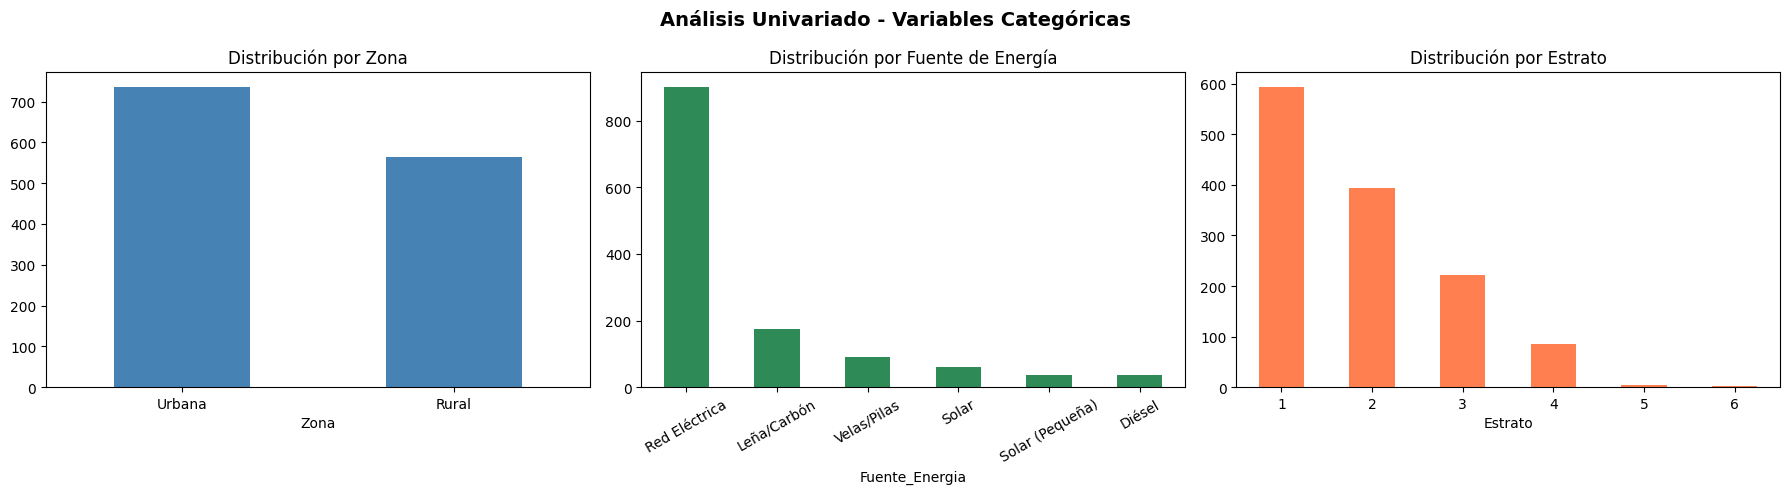

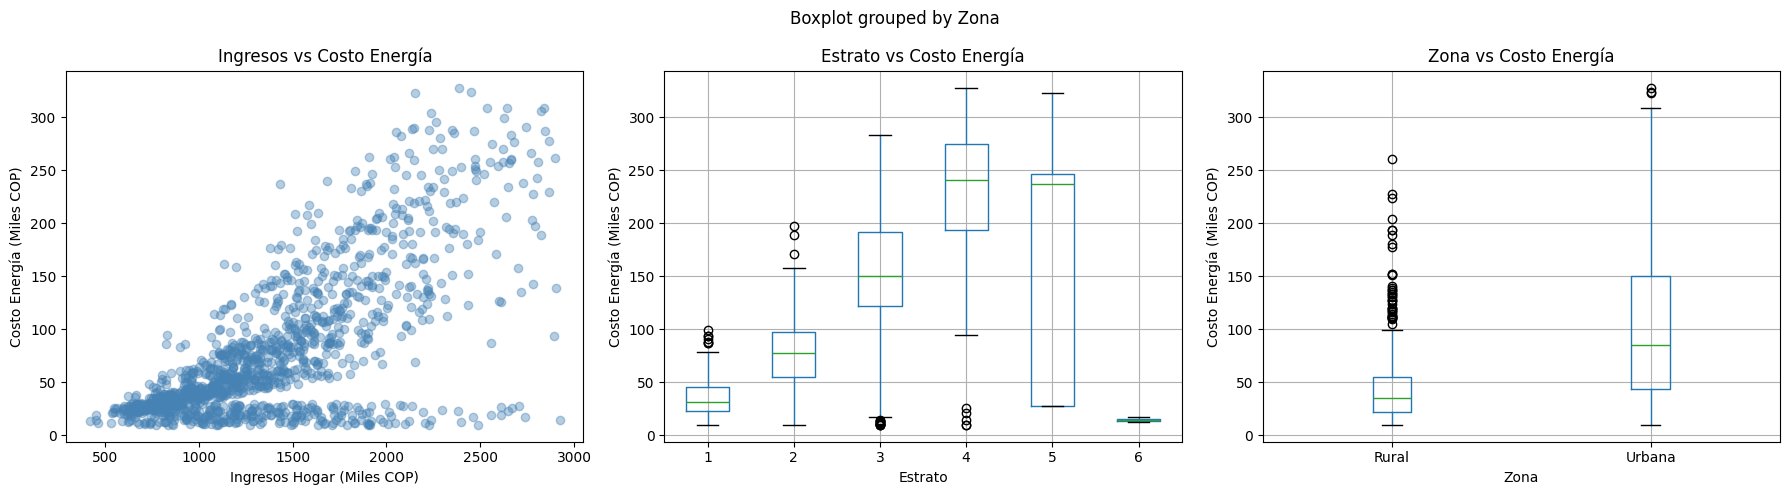

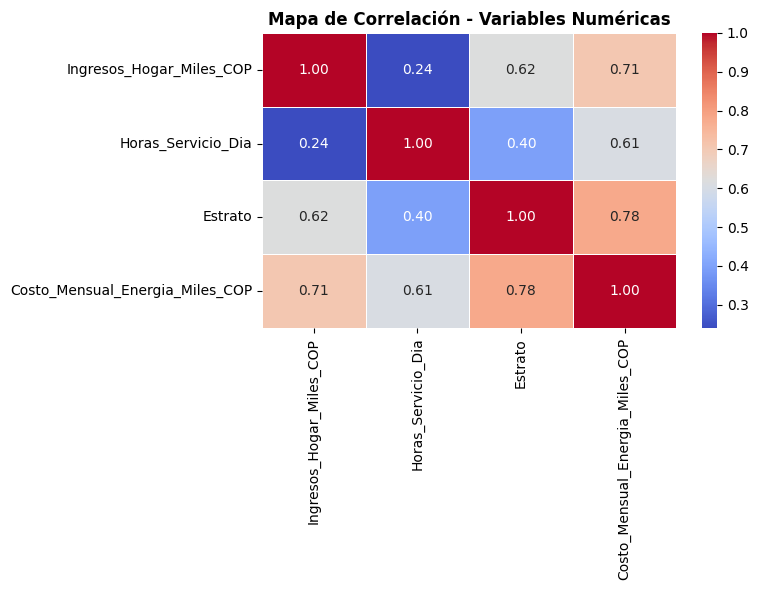

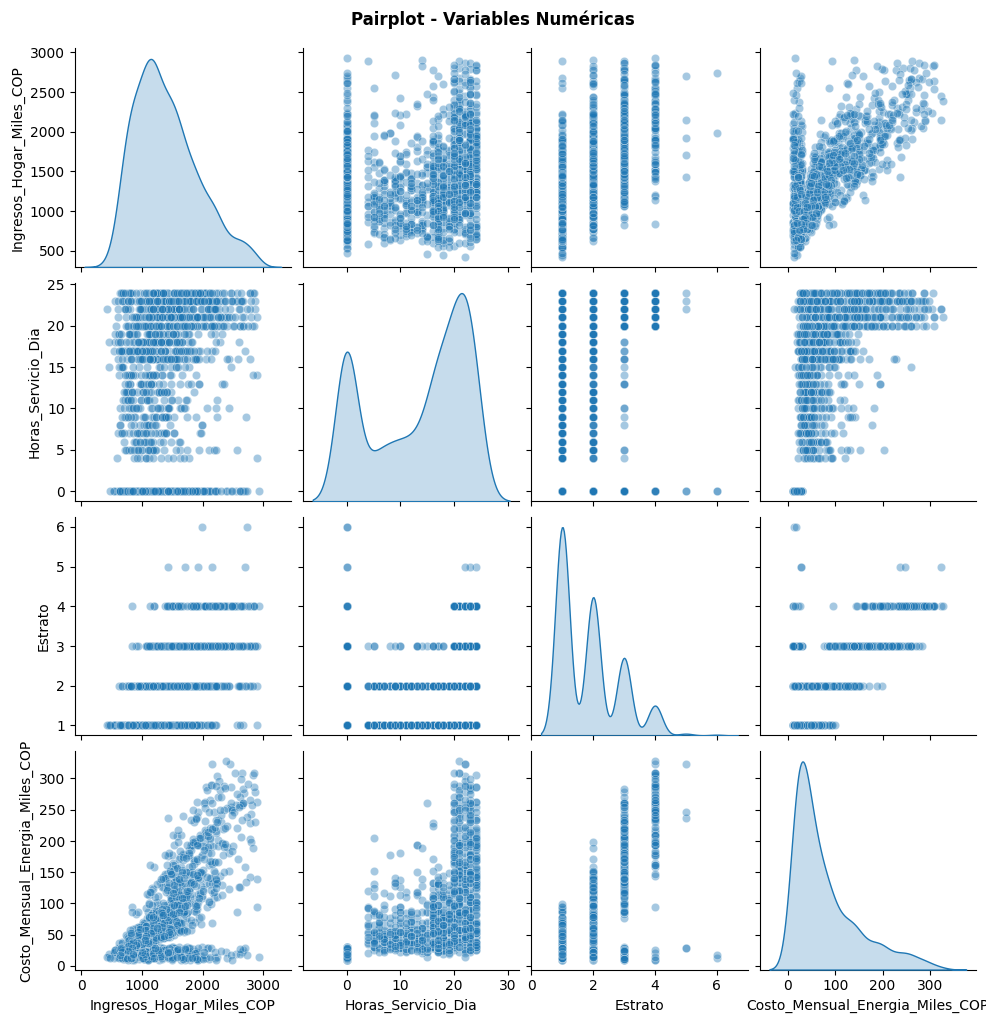


Entrenamiento: 1040 filas | Prueba: 261 filas

📊 Regresión Lineal
   MAE:  21.49
   RMSE: 30.47
   R²:   0.8059

📊 Árbol de Decisión
   MAE:  12.14
   RMSE: 19.07
   R²:   0.9240

📊 Random Forest
   MAE:  9.24
   RMSE: 13.91
   R²:   0.9596

=== TABLA COMPARATIVA DE MODELOS ===
                       MAE     RMSE      R²
Regresión Lineal   21.4890  30.4733  0.8059
Árbol de Decisión  12.1418  19.0660  0.9240
Random Forest       9.2442  13.9067  0.9596


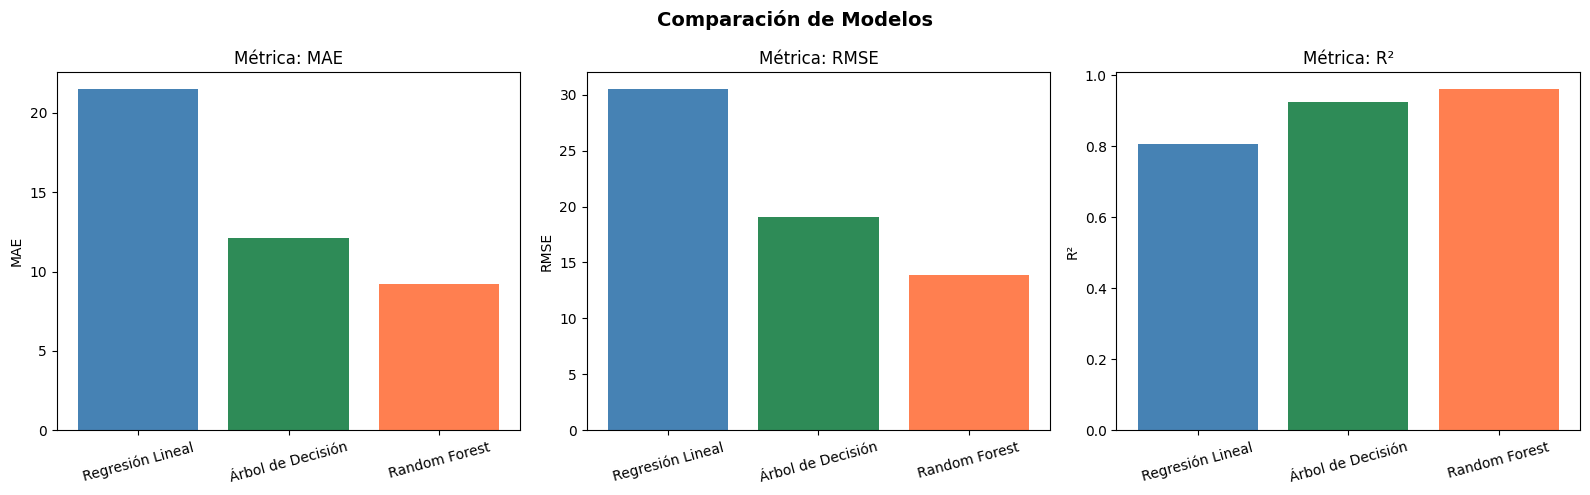

/tmp/ipykernel_10162/2182908489.py:257: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')


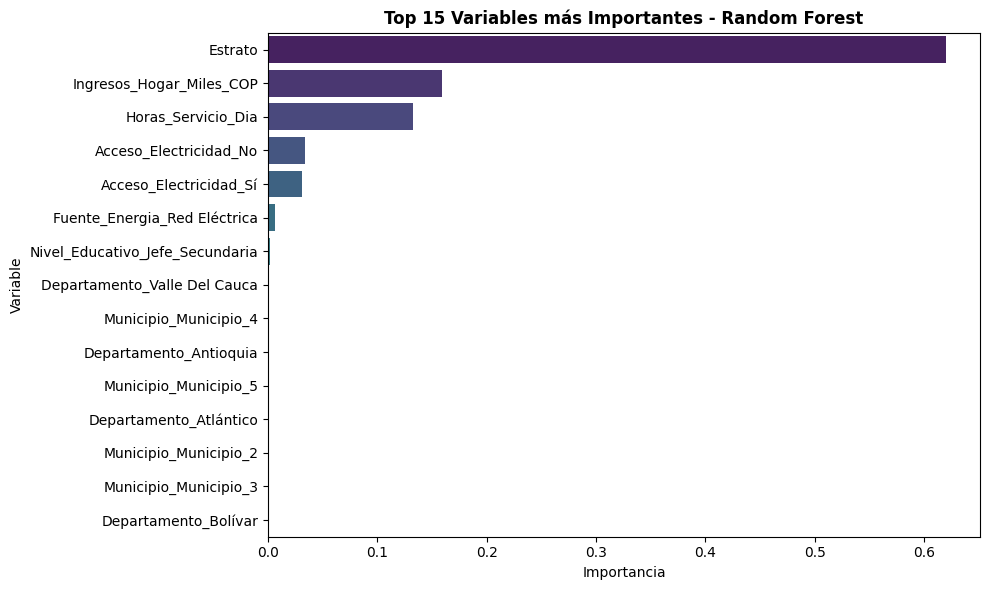


✅ Proyecto completado exitosamente.


In [ ]:
# ============================================================
# PROYECTO FINAL IA - NIVEL EXPLORADOR
# Predicción del costo mensual de energía en hogares de Colombia
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ============================================================
# 1. CARGA E INSPECCIÓN DEL DATASET
# ============================================================
df = pd.read_csv('/content/drive/MyDrive/Bootcamp_IA_sem3/dataset_energia_colombia.csv')

print("=" * 50)
print("FORMA DEL DATASET:", df.shape)
print("\nTIPOS DE DATOS:\n", df.dtypes)
print("\nPRIMERAS FILAS:\n", df.head())
print("\nESTADÍSTICAS BÁSICAS:\n", df.describe())
print("\nVALORES NULOS:\n", df.isnull().sum())


# ============================================================
# 2. LIMPIEZA DE DATOS
# ============================================================

# Duplicados
print("\nDuplicados:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

# Corregir tipos de datos
df['Ingresos_Hogar_Miles_COP']        = pd.to_numeric(df['Ingresos_Hogar_Miles_COP'], errors='coerce')
df['Horas_Servicio_Dia']              = pd.to_numeric(df['Horas_Servicio_Dia'], errors='coerce')
df['Costo_Mensual_Energia_Miles_COP'] = pd.to_numeric(df['Costo_Mensual_Energia_Miles_COP'], errors='coerce')
df['Estrato']                         = pd.to_numeric(df['Estrato'], errors='coerce')

# Limpiar categóricas
cols_cat = ['Departamento', 'Municipio', 'Zona', 'Fuente_Energia',
            'Nivel_Educativo_Jefe', 'Tecnologia_Renovable', 'Acceso_Electricidad']
for col in cols_cat:
    df[col] = df[col].str.strip().str.title()

# Eliminar outliers con IQR
def remove_outliers(df, col):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    return df[(df[col] >= Q1 - 1.5 * IQR) & (df[col] <= Q3 + 1.5 * IQR)]

df = remove_outliers(df, 'Costo_Mensual_Energia_Miles_COP')
df = remove_outliers(df, 'Ingresos_Hogar_Miles_COP')

# Validar rangos lógicos
df = df[df['Horas_Servicio_Dia'].between(0, 24)]
df = df[df['Estrato'].between(1, 6)]

print("\n✅ Dataset limpio - Filas restantes:", df.shape[0])

df.to_csv('/content/drive/MyDrive/Bootcamp_IA_sem3/datasetlimpia_energia_colombia).csv', index=False, encoding='utf-8-sig')

# ============================================================
# 3. ANÁLISIS UNIVARIADO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Univariado - Variables Numéricas', fontsize=14, fontweight='bold')

sns.histplot(df['Costo_Mensual_Energia_Miles_COP'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Distribución: Costo Mensual Energía')
axes[0].set_xlabel('Miles COP')

sns.histplot(df['Ingresos_Hogar_Miles_COP'], kde=True, ax=axes[1], color='seagreen')
axes[1].set_title('Distribución: Ingresos del Hogar')
axes[1].set_xlabel('Miles COP')

sns.histplot(df['Horas_Servicio_Dia'], kde=True, ax=axes[2], color='coral')
axes[2].set_title('Distribución: Horas de Servicio/Día')
axes[2].set_xlabel('Horas')

plt.tight_layout()
plt.show()

# Variables categóricas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Univariado - Variables Categóricas', fontsize=14, fontweight='bold')

df['Zona'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución por Zona')
axes[0].tick_params(axis='x', rotation=0)

df['Fuente_Energia'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen')
axes[1].set_title('Distribución por Fuente de Energía')
axes[1].tick_params(axis='x', rotation=30)

df['Estrato'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='coral')
axes[2].set_title('Distribución por Estrato')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# ============================================================
# 4. ANÁLISIS BIVARIADO
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Análisis Bivariado', fontsize=14, fontweight='bold')

# Ingresos vs Costo
axes[0].scatter(df['Ingresos_Hogar_Miles_COP'],
                df['Costo_Mensual_Energia_Miles_COP'],
                alpha=0.4, color='steelblue')
axes[0].set_xlabel('Ingresos Hogar (Miles COP)')
axes[0].set_ylabel('Costo Energía (Miles COP)')
axes[0].set_title('Ingresos vs Costo Energía')

# Estrato vs Costo (boxplot)
df.boxplot(column='Costo_Mensual_Energia_Miles_COP', by='Estrato', ax=axes[1])
axes[1].set_title('Estrato vs Costo Energía')
axes[1].set_xlabel('Estrato')
axes[1].set_ylabel('Costo Energía (Miles COP)')
plt.sca(axes[1])
plt.title('Estrato vs Costo Energía')

# Zona vs Costo (boxplot)
df.boxplot(column='Costo_Mensual_Energia_Miles_COP', by='Zona', ax=axes[2])
axes[2].set_title('Zona vs Costo Energía')
axes[2].set_xlabel('Zona')
axes[2].set_ylabel('Costo Energía (Miles COP)')
plt.sca(axes[2])
plt.title('Zona vs Costo Energía')

plt.tight_layout()
plt.show()

# ============================================================
# 5. ANÁLISIS MULTIVARIADO
# ============================================================

# Heatmap de correlación
plt.figure(figsize=(8, 6))
corr = df[['Ingresos_Hogar_Miles_COP', 'Horas_Servicio_Dia',
           'Estrato', 'Costo_Mensual_Energia_Miles_COP']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Mapa de Correlación - Variables Numéricas', fontweight='bold')
plt.tight_layout()
plt.show()

# Pairplot
sns.pairplot(df[['Ingresos_Hogar_Miles_COP', 'Horas_Servicio_Dia',
                 'Estrato', 'Costo_Mensual_Energia_Miles_COP']],
             diag_kind='kde', plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot - Variables Numéricas', y=1.02, fontweight='bold')
plt.show()

# ============================================================
# 6. PREPROCESAMIENTO PARA MODELADO
# ============================================================

# Separar X e y
X = df.drop(columns=['Costo_Mensual_Energia_Miles_COP'])
y = df['Costo_Mensual_Energia_Miles_COP']

# Identificar columnas
num_features = ['Horas_Servicio_Dia', 'Ingresos_Hogar_Miles_COP', 'Estrato']
cat_features  = ['Departamento', 'Municipio', 'Zona', 'Acceso_Electricidad',
                 'Nivel_Educativo_Jefe', 'Fuente_Energia', 'Tecnologia_Renovable']

# Preprocesador
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
])

# División train/test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nEntrenamiento: {X_train.shape[0]} filas | Prueba: {X_test.shape[0]} filas")

# ============================================================
# 7. ENTRENAMIENTO DE MODELOS
# ============================================================

modelos = {
    'Regresión Lineal':    LinearRegression(),
    'Árbol de Decisión':   DecisionTreeRegressor(random_state=42),
    'Random Forest':       RandomForestRegressor(n_estimators=100, random_state=42)
}

resultados = {}

for nombre, modelo in modelos.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', modelo)
    ])
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)

    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)

    resultados[nombre] = {'MAE': mae, 'RMSE': rmse, 'R²': r2}
    print(f"\n📊 {nombre}")
    print(f"   MAE:  {mae:.2f}")
    print(f"   RMSE: {rmse:.2f}")
    print(f"   R²:   {r2:.4f}")

# ============================================================
# 8. COMPARACIÓN DE MODELOS
# ============================================================
df_resultados = pd.DataFrame(resultados).T
print("\n=== TABLA COMPARATIVA DE MODELOS ===")
print(df_resultados.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Comparación de Modelos', fontsize=14, fontweight='bold')

colores = ['steelblue', 'seagreen', 'coral']

for i, metrica in enumerate(['MAE', 'RMSE', 'R²']):
    axes[i].bar(df_resultados.index, df_resultados[metrica], color=colores)
    axes[i].set_title(f'Métrica: {metrica}')
    axes[i].set_ylabel(metrica)
    axes[i].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

# ============================================================
# 9. IMPORTANCIA DE VARIABLES (Random Forest)
# ============================================================
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])
pipeline_rf.fit(X_train, y_train)

# Obtener nombres de features
ohe_features = pipeline_rf.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(cat_features)
all_features = num_features + list(ohe_features)

importancias = pipeline_rf.named_steps['model'].feature_importances_
df_imp = pd.DataFrame({'Variable': all_features, 'Importancia': importancias})
df_imp = df_imp.sort_values('Importancia', ascending=False).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importancia', y='Variable', data=df_imp, palette='viridis')
plt.title('Top 15 Variables más Importantes - Random Forest', fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Proyecto completado exitosamente.")
